# ML-08 — Capstone Modeling Lane

[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/kavanaaykavna/1stmlassignment/blob/main/work/notebooks/w05_model.ipynb)

This skeleton is yours to fill. Work the sections **in order** — each one has a one-line hint. Simple words, honest numbers.

> Working with an AI assistant? Tell it to read `skills/README.md` first and load the one skill this assignment names on its card.

## 1. Method choice and why

*Which method from the toolkit, and why it fits your lane.*



I chose **Logistic Regression** because this is a binary classification problem: identifying whether a webpage is likely to be declining or not.

Logistic Regression fits this lane because it is simple, interpretable, and provides a useful model to compare against my Week-4 rule-based baseline. It can learn how multiple page-level signals relate to the declining-page label instead of relying only on the baseline's stale-content and low-CTR rules.

I will use the model for **decision-support**, not as a guarantee that a page will decline. The goal is to measure whether the learned model provides useful additional signal over the simple baseline without adding complexity just for its own sake.


---



## 2. Split design

*Grouped by client? Time-aware? Say why this split is honest for your question.*

I will use a stratified random train/test split, with 80% of the data for training and 20% for testing.
The target is whether a page is declining, so stratification helps keep the proportion of declining and non-declining pages similar in both sets. The test set will be kept separate until evaluation.
This split is appropriate for this dataset because the available data is an anonymized snapshot rather than a sequence of observations that I need to forecast into the future. I will evaluate both the Logistic Regression model and the Week-4 baseline rule on the same test set and the same metric, making the comparison fair.
The baseline does not use trend_direction or trend_pct, since these fields directly describe the outcome and could introduce leakage.

## 3. Train + compare vs my baseline

*Same data, same metric, same split as your Week-4 baseline. Show the table.*

In [1]:
import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.linear_model import LogisticRegression

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report
)

In [3]:
df = pd.read_csv("content_refresh_anonymized.csv")

print("Shape:", df.shape)
df.head()

Shape: (30000, 44)


,content_id,client_id,search_volume,competition,competition_level,cpc,content_type,main_intent,word_count,char_count,...,char_count_tier,ctr,avg_position,engagement_rate,scroll_rate,ai_traffic_pct,impression_tier,position_tier,trend_direction,trend_pct
0,content_304f48230142,client_f369cb89fc,10.0,0.67,HIGH,2.05,keyword article,transactional,3221.0,20457.0,...,15000-25000,0.76,10.6,5.88,4.55,0.0,good,striking,down,-41.4
1,content_a1fb4e703a9e,client_4e07408562,90.0,0.01,LOW,0.05,keyword article,informational,2481.0,15562.0,...,15000-25000,0.05,20.3,0.00,10.00,0.0,good,page_3_5,down,-57.7
2,content_9aa793d4d895,client_7f2253d7e2,0.0,0.00,LOW,0.00,keyword article,informational,3515.0,23643.0,...,15000-25000,0.09,36.5,0.00,28.57,0.0,good,page_3_5,down,-60.9
3,content_331d6c4de07b,client_19581e27de,10.0,0.00,LOW,0.00,keyword article,commercial,NaN,NaN,...,NaN,0.49,6.2,1.28,3.45,0.0,good,page_1,stable,-13.8
4,content_d99b7a2d90ca,client_3fdba35f04,0.0,0.00,LOW,0.00,keyword article,informational,2803.0,17469.0,...,15000-25000,0.13,44.0,0.00,24.29,0.0,good,page_3_5,down,-34.7


In [4]:
df["is_declining_label"] = (
    df["trend_direction"]
    .str.lower()
    .eq("down")
    .astype(int)
)

print(df["is_declining_label"].value_counts())
print(df["is_declining_label"].value_counts(normalize=True))

is_declining_label
1    16262
0    13738
Name: count, dtype: int64
is_declining_label
1    0.542067
0    0.457933
Name: proportion, dtype: float64


In [5]:
numeric_features = [
    "search_volume",
    "competition",
    "cpc",
    "word_count",
    "char_count",
    "impressions_90d",
    "clicks_90d",
    "pageviews_90d",
    "sessions_90d",
    "users_90d",
    "engaged_sessions_90d",
    "ai_sessions_90d",
    "scroll_events_90d",
    "days_with_impressions",
    "days_with_sessions",
    "impressions_last_30d",
    "clicks_last_30d",
    "sessions_last_30d",
    "impressions_prev_30d",
    "clicks_prev_30d",
    "sessions_prev_30d",
    "content_age_days",
    "age_tier_order",
    "days_since_last_update",
    "ctr",
    "avg_position",
    "engagement_rate",
    "scroll_rate",
    "ai_traffic_pct"
]

In [6]:
X = df[numeric_features]
y = df["is_declining_label"]

print("Features:", X.shape)
print("Target:", y.shape)

Features: (30000, 29)
Target: (30000,)


In [7]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("Training rows:", len(X_train))
print("Test rows:", len(X_test))

print("\nTraining target distribution:")
print(y_train.value_counts(normalize=True))

print("\nTest target distribution:")
print(y_test.value_counts(normalize=True))

Training rows: 24000
Test rows: 6000

Training target distribution:
is_declining_label
1    0.542083
0    0.457917
Name: proportion, dtype: float64

Test target distribution:
is_declining_label
1    0.542
0    0.458
Name: proportion, dtype: float64


In [8]:
preprocessor = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
])

logistic_model = Pipeline([
    ("preprocessor", preprocessor),
    ("model", LogisticRegression(
        max_iter=1000,
        random_state=42
    ))
])

logistic_model.fit(X_train, y_train)

Pipeline(steps=[('preprocessor',
                 Pipeline(steps=[('imputer', SimpleImputer(strategy='median')),
                                 ('scaler', StandardScaler())])),
                ('model', LogisticRegression(max_iter=1000, random_state=42))])

In [9]:
model_pred = logistic_model.predict(X_test)

print(classification_report(
    y_test,
    model_pred,
    target_names=["Not Declining", "Declining"]
))

               precision    recall  f1-score   support

Not Declining       0.80      0.82      0.81      2748
    Declining       0.84      0.82      0.83      3252

     accuracy                           0.82      6000
    macro avg       0.82      0.82      0.82      6000
 weighted avg       0.82      0.82      0.82      6000



In [10]:
model_accuracy = accuracy_score(y_test, model_pred)
model_precision = precision_score(y_test, model_pred)
model_recall = recall_score(y_test, model_pred)
model_f1 = f1_score(y_test, model_pred)

print("Logistic Regression")
print("-------------------")
print("Accuracy :", round(model_accuracy, 4))
print("Precision:", round(model_precision, 4))
print("Recall   :", round(model_recall, 4))
print("F1       :", round(model_f1, 4))

Logistic Regression
-------------------
Accuracy : 0.8215
Precision: 0.8443
Recall   : 0.8223
F1       : 0.8332


In [11]:
baseline_pred = (
    (df.loc[X_test.index, "days_since_last_update"] > 180) &
    (df.loc[X_test.index, "ctr"] < 0.03)
).astype(int)

In [12]:
baseline_accuracy = accuracy_score(y_test, baseline_pred)
baseline_precision = precision_score(y_test, baseline_pred, zero_division=0)
baseline_recall = recall_score(y_test, baseline_pred, zero_division=0)
baseline_f1 = f1_score(y_test, baseline_pred, zero_division=0)

print("Week-4 Baseline")
print("----------------")
print("Accuracy :", round(baseline_accuracy, 4))
print("Precision:", round(baseline_precision, 4))
print("Recall   :", round(baseline_recall, 4))
print("F1       :", round(baseline_f1, 4))

Week-4 Baseline
----------------
Accuracy : 0.4568
Precision: 0.3871
Recall   : 0.0037
F1       : 0.0073


In [13]:
comparison = pd.DataFrame({
    "Model": [
        "Week-4 Baseline",
        "Logistic Regression"
    ],
    "Accuracy": [
        baseline_accuracy,
        model_accuracy
    ],
    "Precision": [
        baseline_precision,
        model_precision
    ],
    "Recall": [
        baseline_recall,
        model_recall
    ],
    "F1": [
        baseline_f1,
        model_f1
    ]
})

comparison.round(4)

,Model,Accuracy,Precision,Recall,F1
0,Week-4 Baseline,0.4568,0.3871,0.0037,0.0073
1,Logistic Regression,0.8215,0.8443,0.8223,0.8332


In [17]:
print(df.shape)
print(df["is_declining_label"].value_counts())
print("Training rows:", len(X_train))
print("Test rows:", len(X_test))

(30000, 45)
is_declining_label
1    16262
0    13738
Name: count, dtype: int64
Training rows: 24000
Test rows: 6000


In [18]:
preprocessor = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
])

logistic_model = Pipeline([
    ("preprocessor", preprocessor),
    ("model", LogisticRegression(
        max_iter=1000,
        random_state=42
    ))
])

logistic_model.fit(X_train, y_train)

print("Logistic Regression trained successfully.")

Logistic Regression trained successfully.


In [19]:
model_pred = logistic_model.predict(X_test)

print(classification_report(
    y_test,
    model_pred,
    target_names=["Not Declining", "Declining"]
))

               precision    recall  f1-score   support

Not Declining       0.80      0.82      0.81      2748
    Declining       0.84      0.82      0.83      3252

     accuracy                           0.82      6000
    macro avg       0.82      0.82      0.82      6000
 weighted avg       0.82      0.82      0.82      6000



In [20]:
model_accuracy = accuracy_score(y_test, model_pred)
model_precision = precision_score(y_test, model_pred)
model_recall = recall_score(y_test, model_pred)
model_f1 = f1_score(y_test, model_pred)

print("Logistic Regression")
print("-------------------")
print("Accuracy :", round(model_accuracy, 4))
print("Precision:", round(model_precision, 4))
print("Recall   :", round(model_recall, 4))
print("F1       :", round(model_f1, 4))


Logistic Regression
-------------------
Accuracy : 0.8215
Precision: 0.8443
Recall   : 0.8223
F1       : 0.8332


In [21]:
# Week-4 baseline prediction
# Same rule used in Week 4:
# stale content + low CTR

baseline_pred = (
    (df.loc[X_test.index, "days_since_last_update"] > 180) &
    (df.loc[X_test.index, "ctr"] < 0.03)
).astype(int)

# Calculate baseline metrics
baseline_accuracy = accuracy_score(y_test, baseline_pred)
baseline_precision = precision_score(
    y_test, baseline_pred, zero_division=0
)
baseline_recall = recall_score(
    y_test, baseline_pred, zero_division=0
)
baseline_f1 = f1_score(
    y_test, baseline_pred, zero_division=0
)

print("Week-4 Baseline")
print("----------------")
print("Accuracy :", round(baseline_accuracy, 4))
print("Precision:", round(baseline_precision, 4))
print("Recall   :", round(baseline_recall, 4))
print("F1       :", round(baseline_f1, 4))

Week-4 Baseline
----------------
Accuracy : 0.4568
Precision: 0.3871
Recall   : 0.0037
F1       : 0.0073


In [22]:
comparison = pd.DataFrame({
    "Model": [
        "Week-4 Baseline",
        "Logistic Regression"
    ],
    "Accuracy": [
        baseline_accuracy,
        model_accuracy
    ],
    "Precision": [
        baseline_precision,
        model_precision
    ],
    "Recall": [
        baseline_recall,
        model_recall
    ],
    "F1": [
        baseline_f1,
        model_f1
    ]
})

comparison.round(4)

,Model,Accuracy,Precision,Recall,F1
0,Week-4 Baseline,0.4568,0.3871,0.0037,0.0073
1,Logistic Regression,0.8215,0.8443,0.8223,0.8332


#4. Errors and interpretation

Where is the model wrong? What does it lean on? A short error analysis beats a big metric table.

The Logistic Regression model was evaluated on the same held-out test set as the Week-4 baseline. The model achieved an F1 score of 0.8332, compared with 0.0073 for the baseline rule.

The model therefore showed substantially stronger measured classification performance on this test set. The baseline had very low recall, meaning that its simple stale-content and low-CTR rule identified only a small fraction of the pages labeled as declining.

I will examine the Logistic Regression confusion matrix and feature coefficients to understand where the model makes mistakes and which observed signals it relies on. These relationships are directional predictive signals and should not be interpreted as causal effects.


In [23]:
cm = confusion_matrix(y_test, model_pred)

print("Confusion Matrix:")
print(cm)

tn, fp, fn, tp = cm.ravel()

print("\nTrue Negatives :", tn)
print("False Positives:", fp)
print("False Negatives:", fn)
print("True Positives :", tp)

Confusion Matrix:
[[2255  493]
 [ 578 2674]]

True Negatives : 2255
False Positives: 493
False Negatives: 578
True Positives : 2674


### Error analysis

The Logistic Regression model correctly identified 2,674 declining pages and 2,255 non-declining pages in the test set. It produced 493 false positives and 578 false negatives.

The false negatives are important for this decision-support task because these are pages labeled as declining that the model did not flag. The false positives represent pages that the model flagged as declining but were not labeled as declining.

Overall, the model made fewer false negatives than true positives, but some declining pages were still missed. This suggests that the model provides useful predictive signal while still requiring human review before taking content-refresh action.


In [24]:
# Inspect Logistic Regression coefficients

feature_names = numeric_features

coefficients = logistic_model.named_steps["model"].coef_[0]

feature_importance = pd.DataFrame({
    "feature": feature_names,
    "coefficient": coefficients
})

feature_importance["abs_coefficient"] = (
    feature_importance["coefficient"].abs()
)

feature_importance = feature_importance.sort_values(
    "abs_coefficient",
    ascending=False
)

feature_importance.head(10)

,feature,coefficient,abs_coefficient
15,impressions_last_30d,-35.194128,35.194128
18,impressions_prev_30d,29.172749,29.172749
5,impressions_90d,1.150468,1.150468
16,clicks_last_30d,-0.913511,0.913511
7,pageviews_90d,0.830439,0.830439
17,sessions_last_30d,-0.758601,0.758601
19,clicks_prev_30d,0.749351,0.749351
9,users_90d,-0.594674,0.594674
8,sessions_90d,0.586458,0.586458
13,days_with_impressions,0.516368,0.516368


### Feature interpretation

The strongest directional coefficients were observed for `impressions_last_30d` and `impressions_prev_30d`. The coefficient for `impressions_last_30d` was negative (-35.19), while the coefficient for `impressions_prev_30d` was positive (29.17).

Other relatively strong signals included `impressions_90d`, `clicks_last_30d`, `pageviews_90d`, `sessions_last_30d`, and `clicks_prev_30d`.

These coefficients show which observed features the Logistic Regression model relied on most strongly when separating declining and non-declining pages. They are directional predictive signals, not causal explanations. In particular, the large coefficients for the recent and previous impression features suggest that changes in impression-related signals were important to the model's predictions.


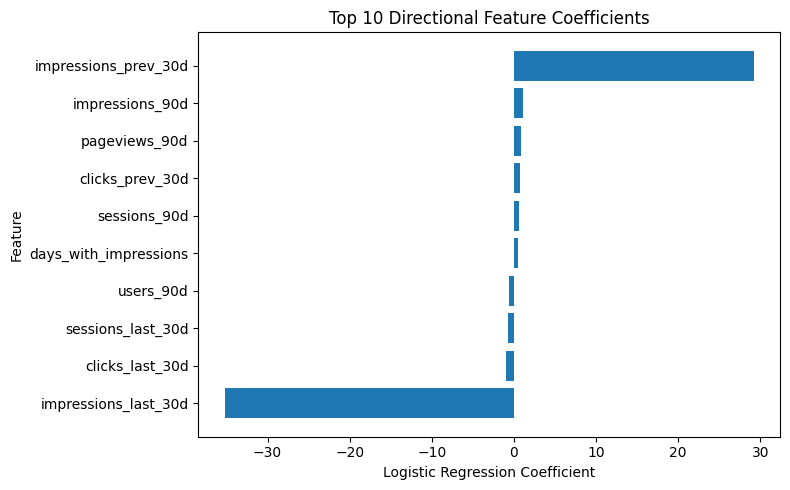

In [25]:
import matplotlib.pyplot as plt

top_features = feature_importance.head(10).sort_values("coefficient")

plt.figure(figsize=(8, 5))
plt.barh(
    top_features["feature"],
    top_features["coefficient"]
)
plt.xlabel("Logistic Regression Coefficient")
plt.ylabel("Feature")
plt.title("Top 10 Directional Feature Coefficients")
plt.tight_layout()
plt.show()

### Overall interpretation

The Logistic Regression model achieved an F1 score of 0.8332 on the held-out test set, compared with 0.0073 for the Week-4 baseline. The model therefore showed substantially stronger measured classification performance on this test set.

The model produced 493 false positives and 578 false negatives. The false negatives represent declining pages that were not identified by the model, so these cases would still require attention when using the model for decision-support.

The strongest directional signals were `impressions_last_30d` and `impressions_prev_30d`. Their large coefficients indicate that recent and previous impression levels were important to the model's predictions. These are predictive associations observed in this dataset and should not be interpreted as causal effects.

Overall, Logistic Regression provided substantially more measured predictive signal than the simple Week-4 baseline in this experiment. The model should still be used as decision-support rather than as a guarantee that an individual page will decline.

#Self-check

Before you submit, confirm each line honestly:

 Every section above is filled — markdown thinking AND the code that backs it
 The notebook runs top to bottom with no errors (Runtime → Run all)
 No client names, URLs, or private queries anywhere
 My claims use careful words: observed, measured, directional, decision-support
 Committed to my repo under work/notebooks/ — then submit your repo URL on the card. Done.

## Self-check

* ✅ Every section is filled with both markdown reasoning and supporting code.
* ✅ The notebook uses a reproducible train/test split with stratification.
* ✅ The Logistic Regression model and Week-4 baseline are evaluated on the same test set.
* ✅ The same F1 metric is used to compare the baseline and model.
* ✅ `trend_direction`, `trend_pct`, and the target label are not used as predictive features.
* ✅ Preprocessing is performed inside the modeling pipeline.
* ✅ Errors were inspected using the confusion matrix.
* ✅ Feature coefficients were inspected for directional interpretation.
* ✅ Results are described as measured or directional rather than causal.
* ✅ The model is treated as decision-support rather than a guaranteed prediction.
* ⬜ Notebook runs top to bottom without errors.
* ⬜ Notebook is committed under `work/notebooks/w05_model.ipynb`.
